In [ ]:
import torch
import torch.nn as nn
from datasets import load_dataset
from transformers import (
    ViTImageProcessor, 
    ViTForImageClassification, 
    TrainingArguments, 
    Trainer,
    DefaultDataCollator
)
from sklearn.metrics import fbeta_score
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from torchvision import transforms


C:\Users\andre\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)

model_name = 'google/vit-base-patch16-224'
id2label = {1: "1_hybrid", 0: "0_non-hybrid"}
label2id = {"1_hybrid": 1, "0_non-hybrid": 0}

processor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

augment = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

model.to(device)

You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4100.30it/s]
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [4]:
def transform(example_batch):
    # Convert images to pixel values and add labels
    images = [augment(x) for x in example_batch['image']]
    inputs = processor(images, return_tensors='pt')
    inputs['labels'] = example_batch['label']
    return inputs

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    preds = np.argmax(logits, axis=1)
    
    f2 = fbeta_score(labels, preds, beta=2, average="binary")
    
    return {"f2": f2}

def prepare_loss_fn():
    labels = prepared_ds["train"].features["label"]

    class_names = labels.names
    num_classes = len(class_names)

    hybrid_idx = class_names.index("1_hybrid")

    class_weights = torch.ones(num_classes, device=device)
    class_weights[hybrid_idx] = 15

    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    return loss_fn

def create_results_folder():
    # create pretrained_vit_results directory if it doesn't exist
    if not os.path.exists("./pretrained_vit_results"):
        os.makedirs("./pretrained_vit_results")

    # get iteration number from existing pretrained_vit_results folders
    existing_folders = [f for f in os.listdir("./pretrained_vit_results") if f.startswith("iteration_")]
    iteration_numbers = [int(f.split("_")[1]) for f in existing_folders]

    # check if folder of max iteration is empty, if so, use that iteration number instead of creating a new one
    if iteration_numbers:
        max_iteration = max(iteration_numbers)
        if not os.listdir(f"./pretrained_vit_results/iteration_{max_iteration}"):
            next_iteration = max_iteration
        else:
            next_iteration = max_iteration + 1
    else:    
        next_iteration = 1
    
    new_folder_path = f"./pretrained_vit_results/iteration_{next_iteration}"
    return new_folder_path   

dataset = load_dataset("imagefolder", data_dir="butterfly_anomaly_image_resized")

prepared_ds = dataset.with_transform(transform)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss = prepare_loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss



In [ ]:
# for param in model.vit.parameters():
#     param.requires_grad = False

# for param in model.vit.encoder.layer[-2:].parameters():
#     param.requires_grad = True

# for param in model.vit.parameters():
#     param.requires_grad = True

training_args = TrainingArguments(
    output_dir=create_results_folder(),
    per_device_train_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=10,
    learning_rate=5e-5,
    lr_scheduler_type="cosine",
    warmup_steps=0.1,
    remove_unused_columns=False,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f2",
    greater_is_better=True,
    weight_decay=0.01,
    seed=42,
)
# Current Best (Iteration 5): Batch Size 32, Learning Rate 5e-5, Num Epochs 10, Weight Decay 0.01, Class Weights 15, Unfreeze all layers

# Iteration 1 - 3: Batch Size 8, 16, 32
# Iteration 4 - 6: Learning Rate 5e-4, 5e-5, 5e-6
# Iteration 7 - 8: Num Epochs 5, 15
# Iteration 9 - 10: Weight Decay 0.05, 0.1
# Iteration 11 - 13: Class Weights 10, 5, 3
# Iteration 14 - 15: Unfreeze last 2 layers, Unfreeze all layers

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=prepared_ds["train"],
    eval_dataset=prepared_ds["validation"],
    data_collator=DefaultDataCollator(),
    compute_metrics=compute_metrics,
)


In [6]:
trainer.train()
trainer.save_model("./final_binary_vit_model")

Epoch,Training Loss,Validation Loss,F2
1,0.218842,0.124574,0.815939
2,0.314729,0.150633,0.897666
3,0.108166,0.104364,0.933099
4,0.031019,0.135734,0.932504
5,0.032413,0.110780,0.930233
6,0.023715,0.098559,0.919118
7,0.006024,0.067363,0.920810
8,0.008706,0.077469,0.927644
9,0.002018,0.052187,0.946691
10,0.002792,0.059719,0.937500


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.52s/it]


Best F2 Score: 0.9467


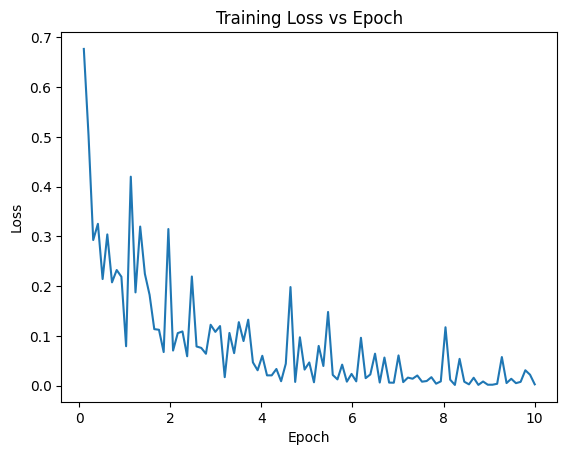

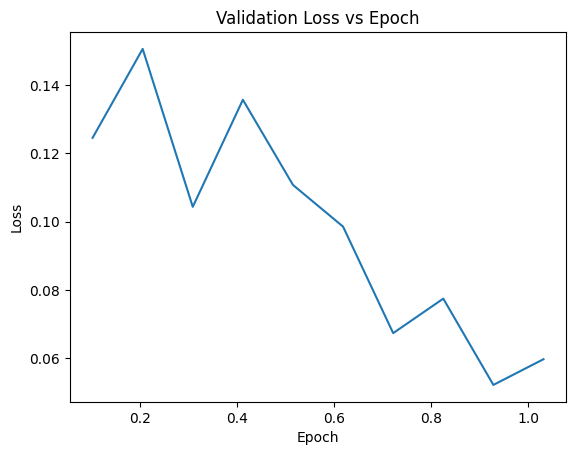

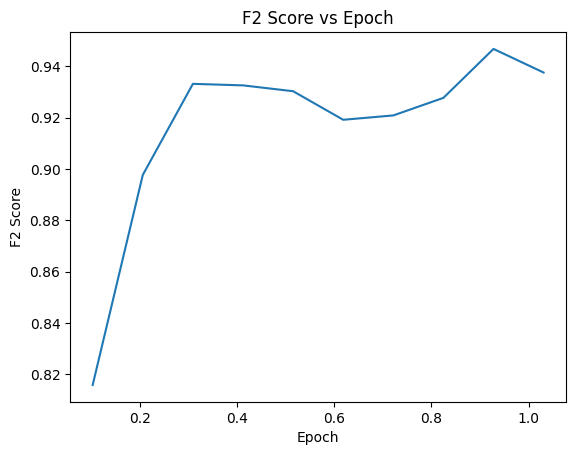

In [ ]:
logs = trainer.state.log_history

train_loss = []
eval_loss = []
f2_scores = []
epochs = []

for log in logs:
    if "loss" in log and "epoch" in log:
        train_loss.append(log["loss"])
        epochs.append(log["epoch"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
    if "eval_f2" in log:
        f2_scores.append(log["eval_f2"])

# Best F2 Score among all epochs
if f2_scores:
    best_f2 = max(f2_scores)
    print(f"Best F2 Score: {best_f2:.4f}")

# Training Loss
plt.figure()
plt.plot(epochs[:len(train_loss)], train_loss)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Validation Loss
if eval_loss:
    plt.figure()
    plt.plot(epochs[:len(eval_loss)], eval_loss)
    plt.title("Validation Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

# F2 Score
if f2_scores:
    plt.figure()
    plt.plot(epochs[:len(f2_scores)], f2_scores)
    plt.title("F2 Score vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("F2 Score")
    plt.show()


In [ ]:
results = {}

base_path = "./pretrained_vit_results"

for folder in os.listdir(base_path):
    if folder.startswith("iteration_"):
        for checkpoint in os.listdir(os.path.join(base_path, folder)):
            path = os.path.join(base_path, folder, checkpoint, "trainer_state.json")
            if os.path.exists(path):
                with open(path) as f:
                    state = json.load(f)

                if folder not in results:
                    results[folder] = []

                results[folder].append(state.get("best_metric"))

# Print results
print(f"{'Iteration':<15} {'Best F2 Score':<15}")
for iteration, f2_list in sorted(results.items(), key=lambda x: int(x[0].split("_")[1])):
    # Get the best F2 score among all checkpoints in this iteration
    f2 = max(f2_list)  
    print(f"{iteration:<15} {f2}")
    

Iteration       Best F2 Score  
iteration_1     0.8545454545454545
iteration_2     0.8828828828828829
iteration_3     0.8896797153024911
iteration_4     0.8880994671403197
iteration_5     0.8938053097345132
iteration_6     0.8938053097345132
iteration_7     0.890652557319224
iteration_8     0.8938053097345132
iteration_9     0.8938053097345132
iteration_10    0.8938053097345132
iteration_11    0.7470414201183432
iteration_12    0.7704654895666132
iteration_13    0.7809847198641766
iteration_14    0.9171075837742504
iteration_15    0.9466911764705882
